# ***Importing Laiblaries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ***Exploratory Data Analysis (EDA)***

In [ ]:
df = pd.read_csv("yield_df.csv")
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
df["Year"].max()

np.int64(2013)

In [ ]:
df.tail()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76
28241,28241,Zimbabwe,Wheat,2013,22888,657.0,2550.07,19.76


In [ ]:
df.shape

(28242, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [ ]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [ ]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [ ]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:
df.isna().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(2310)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
obj_df = df.select_dtypes(include="object")

In [ ]:
num_df = df.select_dtypes(include="number")

# *Data Visaulization*

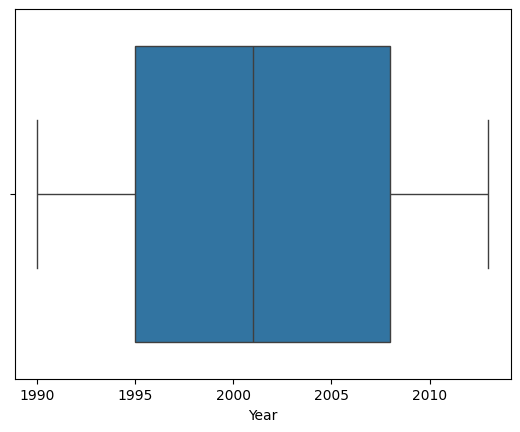

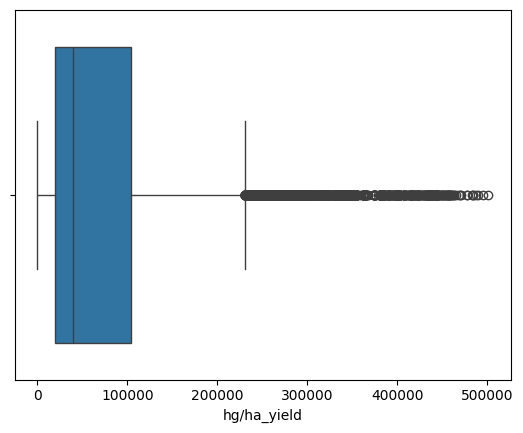

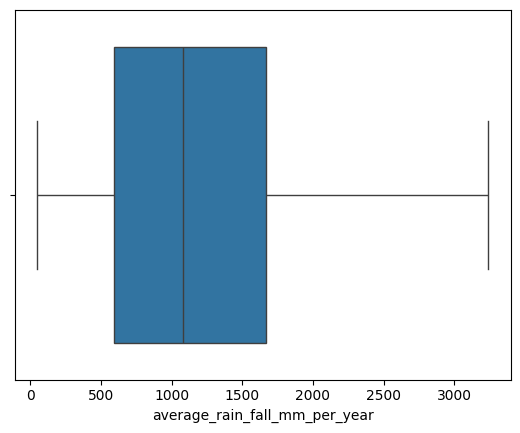

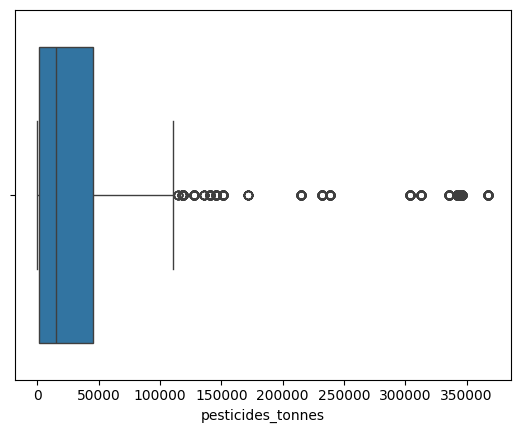

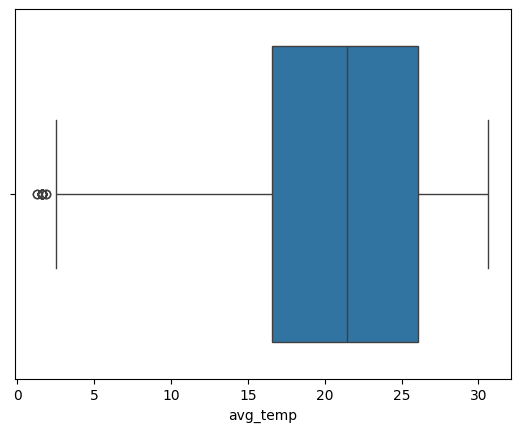

In [ ]:
for col in num_df.columns:
    sns.boxplot(data=df, x=col)
    plt.show()


In [ ]:
for col in num_df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


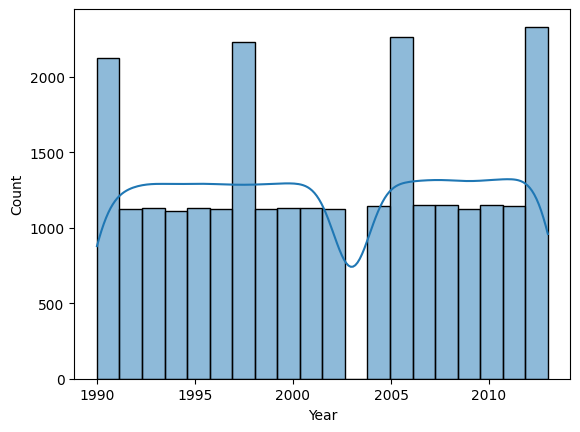

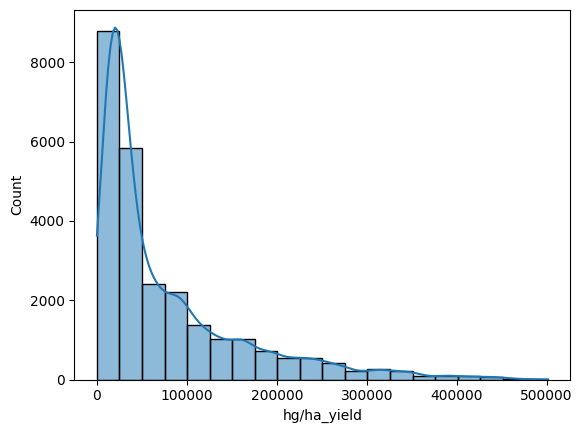

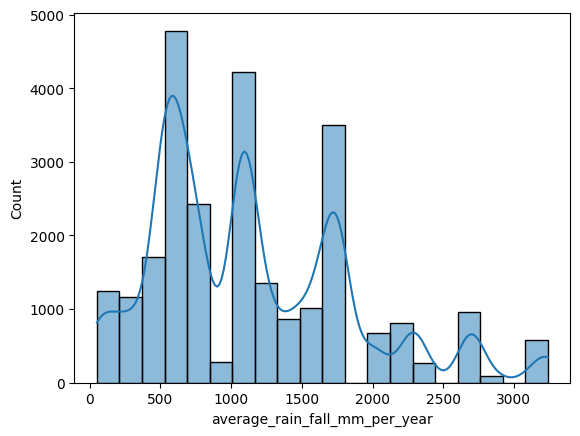

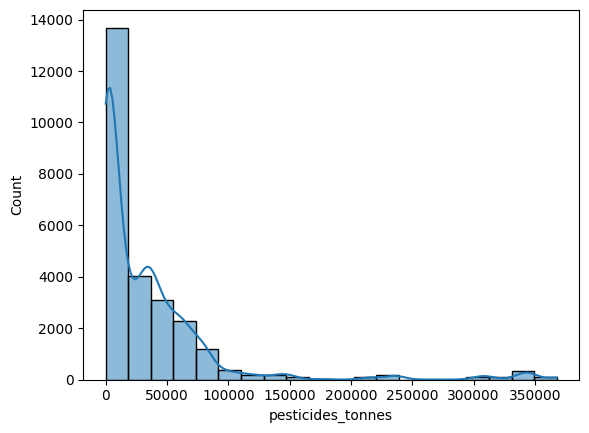

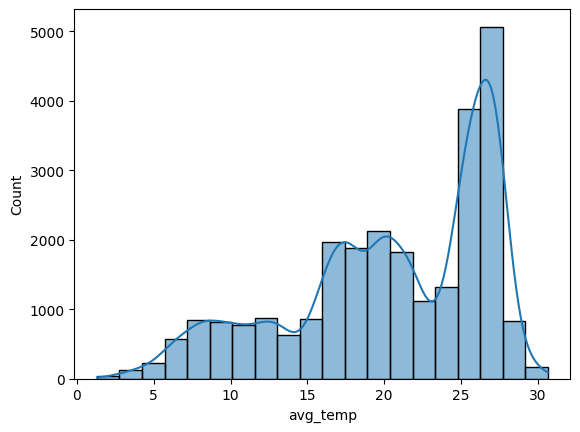

In [ ]:
for col in num_df.columns:
    sns.histplot(num_df[col], bins=20, kde=True)
    plt.show()

In [ ]:
df["Area"].value_counts().count()

np.int64(101)

<Axes: xlabel='count', ylabel='Area'>

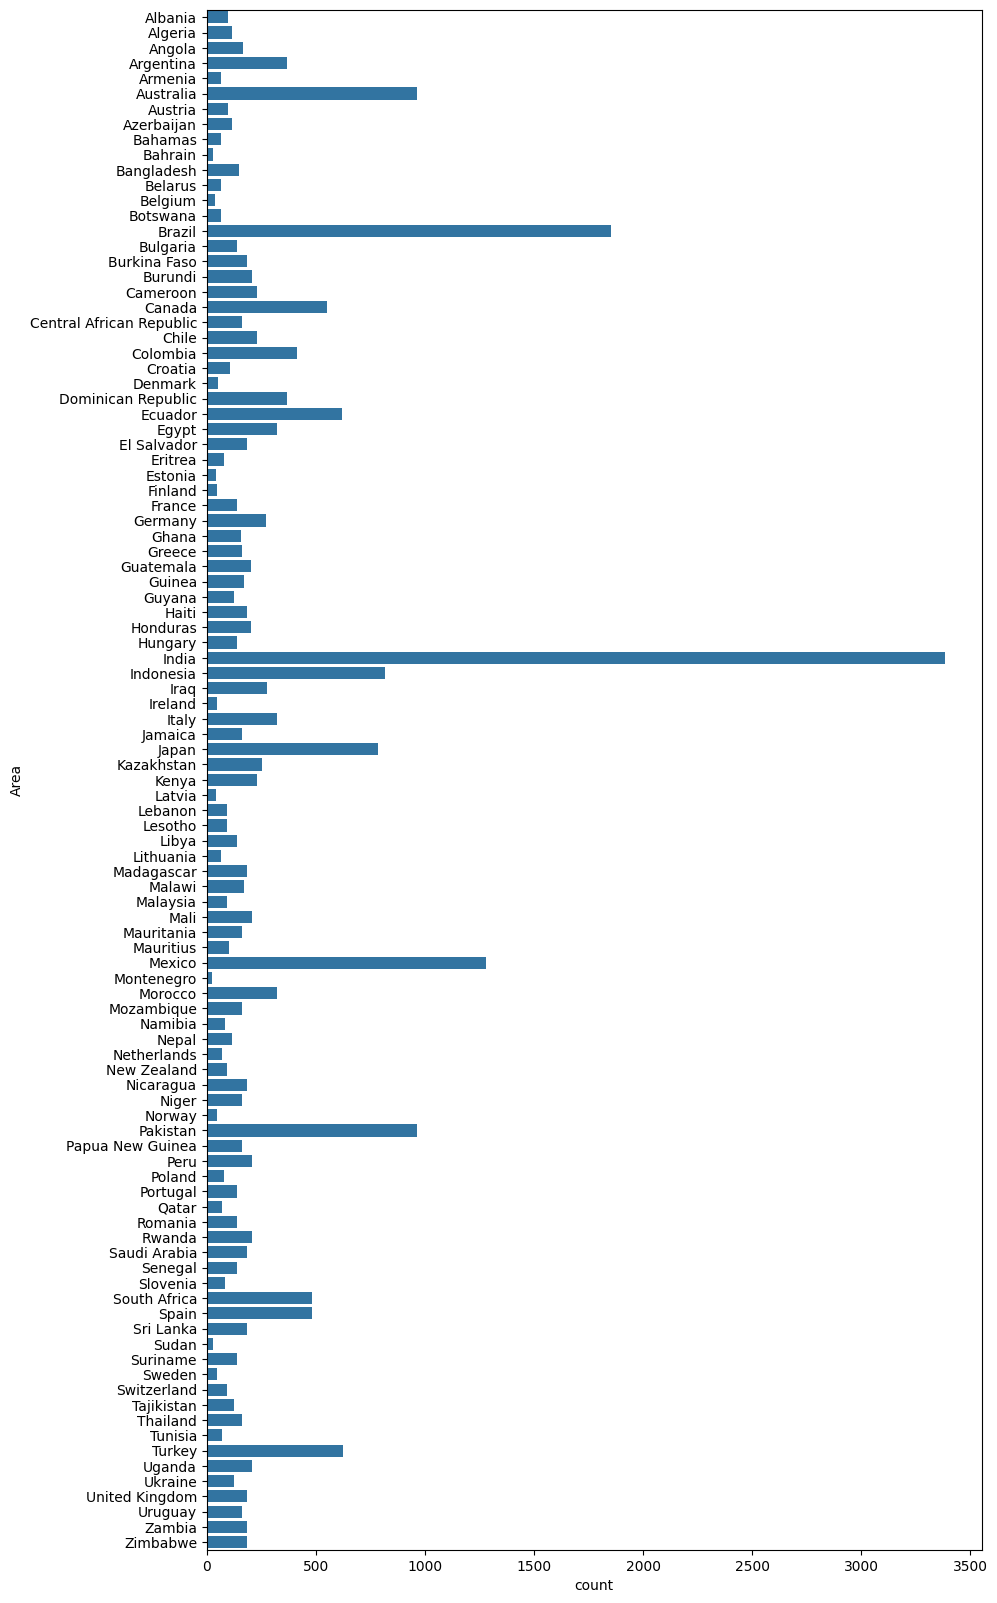

In [ ]:
plt.figure(figsize=(10,20))
sns.countplot(df["Area"])

<Axes: ylabel='Item'>

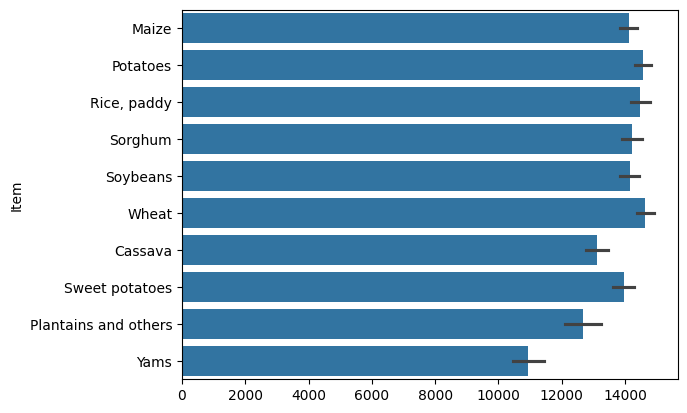

In [ ]:
sns.barplot(df["Item"])

In [ ]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

<Axes: xlabel='avg_temp', ylabel='Item'>

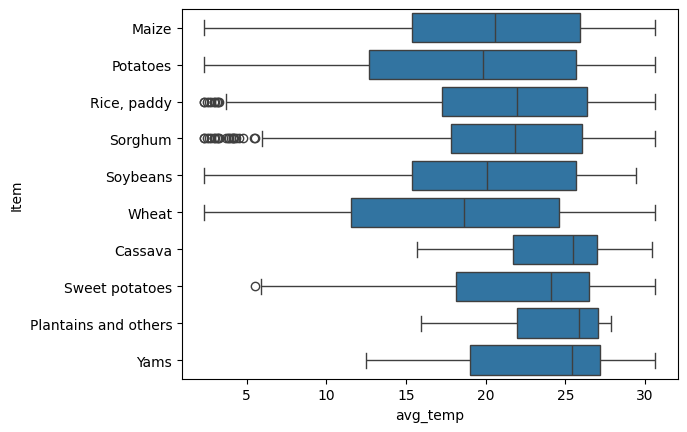

In [ ]:
sns.boxplot(data=df,x='avg_temp',y='Item')

<Axes: xlabel='average_rain_fall_mm_per_year', ylabel='Item'>

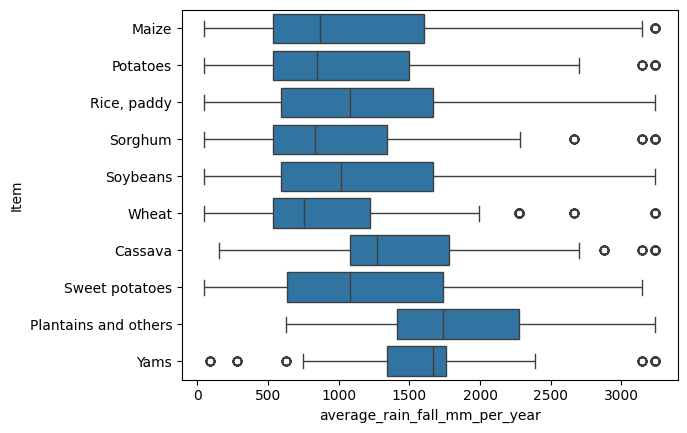

In [ ]:
sns.boxplot(data=df,x='average_rain_fall_mm_per_year',y='Item')

# ***Data Preprocessing***

In [ ]:
df["rain_temp"] = df["average_rain_fall_mm_per_year"] * df["avg_temp"]

In [ ]:
X = df.drop("hg/ha_yield",axis=1)
y = df["hg/ha_yield"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
le = LabelEncoder()

cat_columns = X_train.select_dtypes(include='object').columns

for col in cat_columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [ ]:
rfr = RandomForestRegressor()
rfr.fit(X_train,y_train)
print("training accuracy:",rfr.score(X_train,y_train))
y_pred = rfr.predict(X_test)
print("R2:",r2_score(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))

training accuracy: 0.9976363380211903
R2: 0.9838204043476819
RMSE: 8970.328128016425


In [ ]:
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rfr.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
1,Item,0.673496
4,pesticides_tonnes,0.098997
0,Area,0.065675
5,avg_temp,0.052112
6,rain_temp,0.048490
3,average_rain_fall_mm_per_year,0.038234
2,Year,0.022996


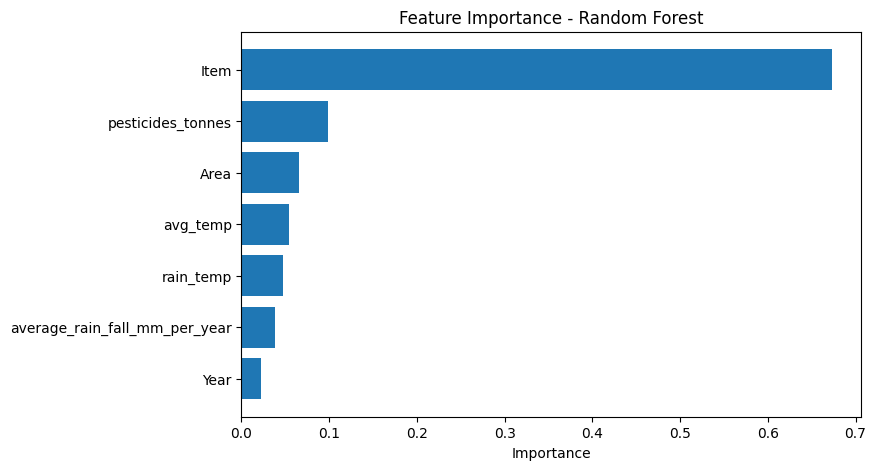

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()